Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
# new add for CNN
from tensorflow import keras
from tensorflow.keras import layers, models

Set Dataset Path

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/A2b/data3a/training"
VAL_DIR = "/content/drive/MyDrive/A2b/data3a/validation"

# Required class names
CLASSES = ["00-none", "01-minor", "02-moderate", "03-severe"]


Data Loading Function

In [ ]:
def load_dataset(path, img_size=128):
    X, y = [], []
    for class_name in CLASSES:
        class_path = os.path.join(path, class_name)

        # Check if class folder exists
        if not os.path.exists(class_path):
            print(f"Missing folder: {class_path}")
            continue

        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)

            # Try loading the image
            try:
                img = cv2.imread(file_path)
                if img is None:
                    continue
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = img.flatten()

                X.append(img)
                y.append(CLASSES.index(class_name))

            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

    return np.array(X), np.array(y)

Load Training + Validation Data

In [ ]:
X_train, y_train = load_dataset(TRAIN_DIR)
X_val, y_val = load_dataset(VAL_DIR)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 1810
Validation samples: 323


Hyperparameter Tuning for Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Randomized search for Random Forest hyperparameters
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],    # Range of tree numbers
    'max_depth': [10, 20, None],                    # Max depth of trees
    'min_samples_split': [2, 5, 10],                # Minimum samples to split node
    'min_samples_leaf': [1, 2, 4],                  # Minimum samples in leaf
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Randomized search with cross-validation
random_search_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf,
                                     n_iter=10, cv=3, n_jobs=-1, verbose=2, random_state=42)

random_search_rf.fit(X_train, y_train)

# Best Parameters for Random Forest
print("Best parameters for Random Forest:", random_search_rf.best_params_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Random Forest: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}


Train and Save Best Random Forest (First ML)

In [ ]:
# Train with best parameters and evaluate
best_rf = random_search_rf.best_estimator_
rf_preds = best_rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, rf_preds))
print(classification_report(y_val, rf_preds))

# Save the best Random Forest model
joblib.dump(best_rf, "/content/drive/MyDrive/A2b/rf_model_best.pkl")
print("Best Random Forest model saved.")

Random Forest Accuracy: 0.5077399380804953
              precision    recall  f1-score   support

           0       0.64      0.57      0.61        75
           1       0.57      0.65      0.61        82
           2       0.42      0.33      0.37        75
           3       0.41      0.47      0.44        91

    accuracy                           0.51       323
   macro avg       0.51      0.51      0.51       323
weighted avg       0.51      0.51      0.51       323

Best Random Forest model saved.


Hyperparameter Tuning for SVM

In [ ]:
# Randomized search for SVM hyperparameters
param_dist_svm = {
    'C': [0.1, 1, 10, 100],       # Regularization parameter
    'kernel': ['linear', 'rbf'],   # Kernel types
    'gamma': ['scale', 'auto'],    # Kernel coefficients
}

# Initialize the SVM Classifier
svm = SVC(probability=True)

# Randomized search with cross-validation
random_search_svm = RandomizedSearchCV(svm, param_distributions=param_dist_svm,
                                       n_iter=5, cv=2, n_jobs=-1, verbose=2, random_state=42)

random_search_svm.fit(X_train, y_train)

# Best Parameters for SVM
print("Best parameters for SVM:", random_search_svm.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters for SVM: {'kernel': 'rbf', 'gamma': 'scale', 'C': 100}


Train and Save Best SVM (Second ML Model)

In [ ]:
# Train with best parameters and evaluate
best_svm = random_search_svm.best_estimator_
svm_preds = best_svm.predict(X_val)

print("SVM Accuracy:", accuracy_score(y_val, svm_preds))
print(classification_report(y_val, svm_preds))

# Save the best SVM model
joblib.dump(best_svm, "/content/drive/MyDrive/A2b/svm_model_best.pkl")
print("Best SVM model saved.")

SVM Accuracy: 0.48297213622291024
              precision    recall  f1-score   support

           0       0.58      0.60      0.59        75
           1       0.51      0.61      0.55        82
           2       0.32      0.29      0.31        75
           3       0.50      0.43      0.46        91

    accuracy                           0.48       323
   macro avg       0.48      0.48      0.48       323
weighted avg       0.48      0.48      0.48       323

Best SVM model saved.


 Cross-validation Evaluation (Random Forest)

In [ ]:
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)
print("Random Forest Cross-validation scores:", rf_cv_scores)
print("Random Forest CV Mean Accuracy:", rf_cv_scores.mean())


Random Forest Cross-validation scores: [0.41436464 0.45303867 0.44475138 0.48895028 0.4281768 ]
Random Forest CV Mean Accuracy: 0.4458563535911602


Cross-validation Evaluation (SVM)

In [ ]:
svm_cv_scores = cross_val_score(best_svm, X_train, y_train, cv=5)
print("SVM Cross-validation scores:", svm_cv_scores)
print("SVM CV Mean Accuracy:", svm_cv_scores.mean())

SVM Cross-validation scores: [0.39226519 0.43922652 0.42265193 0.47513812 0.46132597]
SVM CV Mean Accuracy: 0.43812154696132594


Confusion Matrix Helper

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

Plot Confusion Matrices

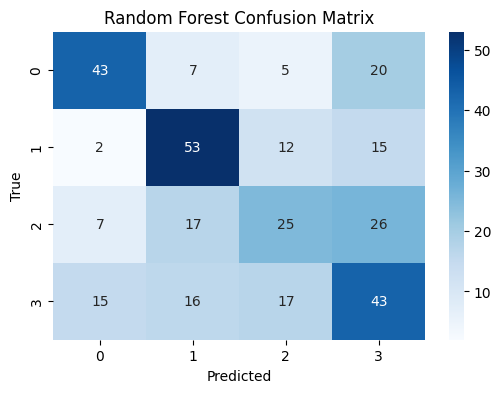

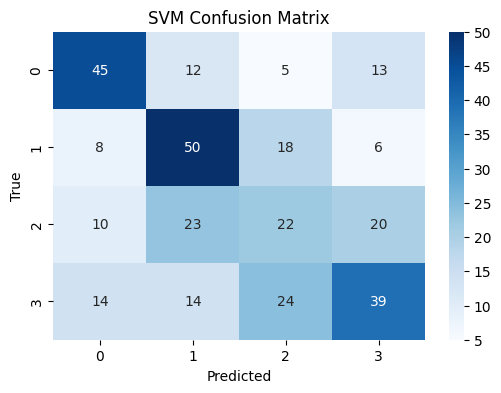

In [ ]:
plot_cm(y_val, rf_preds, "Random Forest Confusion Matrix")
plot_cm(y_val, svm_preds, "SVM Confusion Matrix")


Visualize Predictions for Random Forest

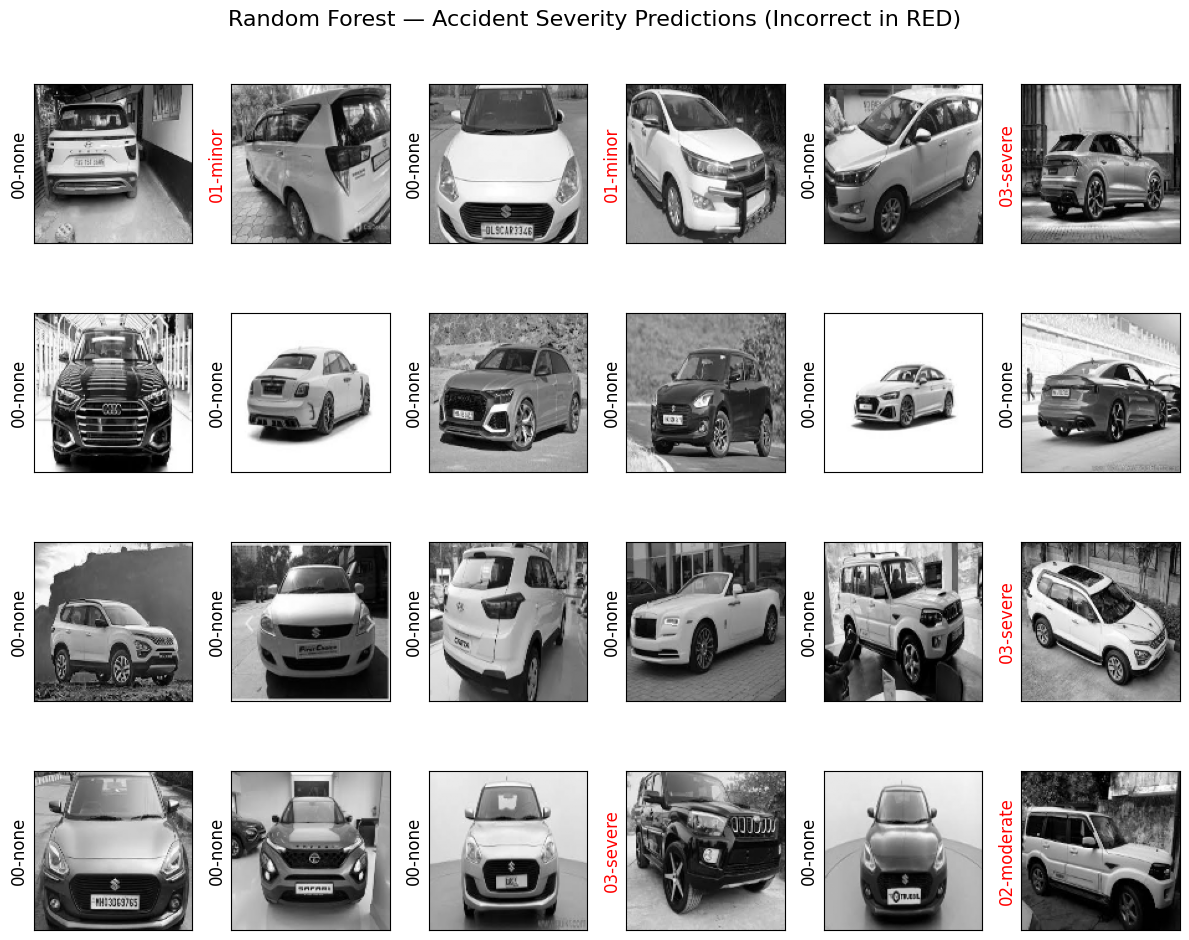

In [ ]:
fig, ax = plt.subplots(4, 6, figsize=(12, 10))

for i, axi in enumerate(ax.flat):
    if i >= len(X_val):
        break

    axi.imshow(X_val[i].reshape(128, 128), cmap='gray')
    axi.set_xticks([])
    axi.set_yticks([])

    true_label = CLASSES[y_val[i]]
    pred_label = CLASSES[rf_preds[i]]

    color = 'black' if rf_preds[i] == y_val[i] else 'red'
    axi.set_ylabel(pred_label, color=color, fontsize=12)

fig.suptitle("Random Forest — Accident Severity Predictions (Incorrect in RED)", fontsize=16)
plt.tight_layout()
plt.show()


Visualize Predictions for SVM

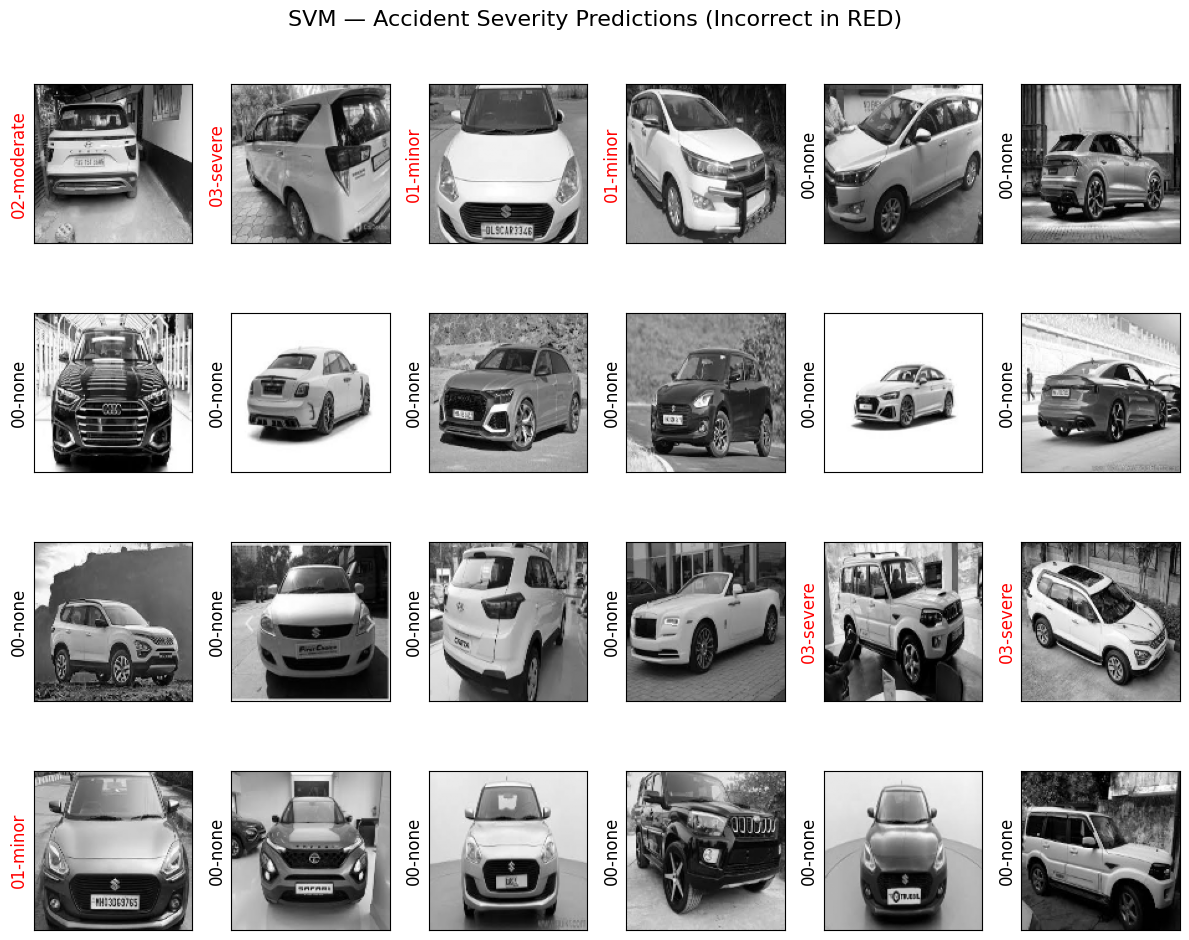

In [18]:
fig, ax = plt.subplots(4, 6, figsize=(12, 10))

for i, axi in enumerate(ax.flat):
    if i >= len(X_val):
        break

    axi.imshow(X_val[i].reshape(128, 128), cmap='gray')
    axi.set_xticks([])
    axi.set_yticks([])

    true_label = CLASSES[y_val[i]]
    pred_label = CLASSES[svm_preds[i]]

    color = 'black' if svm_preds[i] == y_val[i] else 'red'
    axi.set_ylabel(pred_label, color=color, fontsize=12)

fig.suptitle("SVM — Accident Severity Predictions (Incorrect in RED)", fontsize=16)
plt.tight_layout()
plt.show()


In [19]:
print(X_train.shape, X_val.shape)
print(X_train[0].shape, X_val[0].shape)


(1810, 16384) (323, 16384)
(16384,) (16384,)


Reshape Existing Data for CNN

In [20]:
# CNN reshape

IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 1

# Reshape flattened grayscale to CNN shape
X_train_cnn = X_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)
X_val_cnn = X_val.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)

# Normalize
X_train_cnn = X_train_cnn.astype("float32") / 255.0
X_val_cnn = X_val_cnn.astype("float32") / 255.0

print("CNN Training shape: ", X_train_cnn.shape)
print("CNN Validation shape: ", X_val_cnn.shape)

CNN Training shape:  (1810, 128, 128, 1)
CNN Validation shape:  (323, 128, 128, 1)


Build CNN Model

In [21]:
def build_cnn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=4):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy", # integer labels (0-3)
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,620 (16.36 MB)

 Trainable params: 4,287,620 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Train CNN

In [22]:
EPOCHS = 15 # can be adjust based on accuracy

history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=32
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2808 - loss: 1.3970 - val_accuracy: 0.4303 - val_loss: 1.2551
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.4607 - loss: 1.1845 - val_accuracy: 0.4644 - val_loss: 1.1460
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5074 - loss: 1.0933 - val_accuracy: 0.5077 - val_loss: 1.0783
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5535 - loss: 1.0055 - val_accuracy: 0.5139 - val_loss: 1.0694
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6094 - loss: 0.9142 - val_accuracy: 0.5480 - val_loss: 1.0569
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6530 - loss: 0.8108 - val_accuracy: 0.5449 - val_loss: 1.0743
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7008 - loss: 0.6944 - val_accuracy: 0.5542 - val_loss: 1.0910
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7778 - loss: 0.5946 - val_accuracy: 0.5511 - val_loss:

Evaluate CNN

In [23]:
val_loss, val_acc = cnn_model.evaluate(X_val_cnn, y_val)
print(f"CNN Validation Accuracy: {val_acc:.4f}")

cnn_preds = np.argmax(cnn_model.predict(X_val_cnn), axis=-1)

print("CNN Classification Report:")
print(classification_report(y_val, cnn_preds, target_names=CLASSES))

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.5981 - loss: 1.7846
CNN Validation Accuracy: 0.5573
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step
CNN Classification Report:
              precision    recall  f1-score   support

     00-none       0.80      0.63      0.70        75
    01-minor       0.61      0.61      0.61        82
 02-moderate       0.40      0.36      0.38        75
   03-severe       0.49      0.62      0.55        91

    accuracy                           0.56       323
   macro avg       0.57      0.55      0.56       323
weighted avg       0.57      0.56      0.56       323



CNN Confusion Matrix

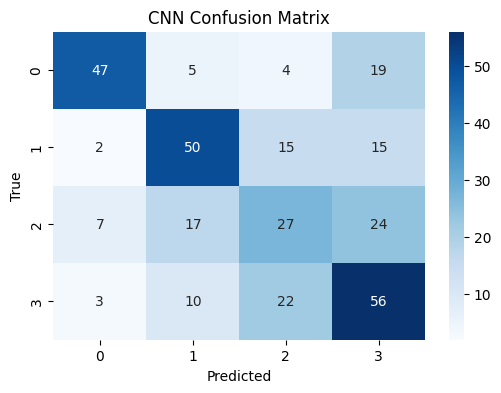

In [24]:
plot_cm(y_val, cnn_preds, "CNN Confusion Matrix")

Save the CNN Model

In [25]:
cnn_model.save("/content/drive/MyDrive/A2b/cnn_model.h5")
print("CNN Model saved successfully.")

CNN Model saved successfully.


CNN -> Accident Multiplier Function

In [26]:
#Accepts a raw image (cv2 format), resizes to 128x128, normalizes it and returns accident severity multiplier
def get_predicted_multiplier(image_input, model=cnn_model):
  #Resize
  try:
    img_resized = cv2.resize(image_input, (IMG_HEIGHT, IMG_WIDTH))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
  except:
    # Fallback: if it's already grayscale or smth goes wrong, still ensure the correct size
    gray = cv2.resize(image_input, (IMG_HEIGHT, IMG_WIDTH))

  # Normalize to [0, 1]
  gray = gray.astype("float32") / 255.0

  # Reshape to (1, H, W, 1) for CNN
  img_reshaped = gray.reshape(-1, IMG_HEIGHT, IMG_WIDTH, CHANNELS)

  # Predict
  prediction = model.predict(img_reshaped, verbose=0)
  predicted_class = int(np.argmax(prediction))

  # Map predicted class to multiplier
  ACCIDENT_MULTIPLIER = 2.0 # global multiplier

  NO_ACC = 1.0
  MINOR = 1.25
  MODERATE = 1.50
  SEVERE = 3.0

  if predicted_class == 0:
      return NO_ACC
  elif predicted_class == 1:
      return MINOR * ACCIDENT_MULTIPLIER
  elif predicted_class == 2:
      return MODERATE * ACCIDENT_MULTIPLIER
  elif predicted_class == 3:
      return SEVERE * ACCIDENT_MULTIPLIER
  else:
      return NO_ACC

